# Fake and Real News Modelling



## Team
- Ajul Thomas
- Chamreunsathya Bin

# Loading data

In [1]:
import pandas as pd


def data_extract(df, target_value):
    """
    Extracts the text and title from the dataframe and  adds a label column.
    """

    # add a target column to the dataframe
    df["label"] = target_value

    # return a df copy with text, title and label columns
    return df[["text", "title", "label"]]


DATA_CONFIG = [
    {
        "filename": "BuzzFeed_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "BuzzFeed_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "filename": "PolitiFact_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "PolitiFact_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {"filename": "Fake.csv", "extract_func": data_extract, "target_value": "FAKE"},
    {"filename": "True.csv", "extract_func": data_extract, "target_value": "TRUE"},
]


def load_merge_data(data_config):
    """
    Loads and merges the data from the given config.
    """
    dataframes = []

    for config in data_config:
        filepath = f"./data/{config['filename']}"
        df = pd.read_csv(filepath)
        df = config["extract_func"](df, config["target_value"])
        dataframes.append(df)

    # concatenate all dataframes into one
    merged_df = pd.concat(dataframes, ignore_index=True)

    return merged_df


def basic_sanity_check(df):
    """
    Performs a basic sanity check on the dataframe.
    """

    # sanity check title
    print("=" * 20)
    print("{:^20}".format("Sanity Check"))
    print("=" * 20)

    # check for missing values
    if df.isnull().values.any():
        print("Missing values found in the dataframe.")
        # remove rows with missing values
        df = df.dropna()

    # check for duplicates
    if df.duplicated().any():
        # check for duplicate rows
        duplicate_rows = df.duplicated().sum()
        print(f"Duplicate rows found: {duplicate_rows}")
        # remove duplicate rows
        df = df.drop_duplicates().reset_index(drop=True)
        print("Duplicate rows removed.")

    # check for empty strings
    if (df["text"] == "").any() or (df["title"] == "").any():
        print("Empty strings found in the dataframe.")
        # remove rows with empty strings
        df = df[(df["text"] != "") & (df["title"] != "")].reset_index(drop=True)
        print("Empty strings removed.")

    # check the shape of the dataframe
    print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns.")
    print(f"Dataframe has {df['label'].nunique()} unique labels.")

    print("=" * 20)


def save_data(df, path):
    """
    Saves the dataframe to a csv file.
    """
    df.to_csv(path, index=False)
    print(f"Data saved to {path}")


def generate_raw_data():
    raw_data = load_merge_data(DATA_CONFIG)
    basic_sanity_check(raw_data)
    save_data(raw_data, "./data/raw_data.csv")
    return raw_data


def load_raw_data():
    """
    Loads the raw data from the given path.
    """
    filepath = "./data/raw_data.csv"

    # check if the file exists, if not generate the raw data
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"{filepath} not found. Generating raw data...")
        df = generate_raw_data()
        print(f"Raw data generated and saved to {filepath}.")
    return df

# Data Preprocessing

In [2]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Custom stopwords (retain "not" and "can")
STOP_WORDS = set(stopwords.words("english")) - {"not", "can"}

# custom stopwords
CUSTOM_STOP_WORDS = {"reuters", "reuter"}

# Combine the two sets of stopwords
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOP_WORDS)


# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r"@\w+", "", text)  # Remove @name
    text = re.sub(r"[^a-zA-Z0-9\s\?]", "", text)  # Remove special characters except "?"
    text = re.sub(r"([^\w\s\?])", "", text)  # Remove punctuations except "?"
    text = re.sub(
        r"\s+", " ", text
    ).strip()  # Remove extra spaces and trailing whitespaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # remove stopwords
    text = " ".join([word for word in text.split() if word not in STOP_WORDS])

    return text


# function to tokenize the text and remove stopwords
def tokenize_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return tokens


def lemmatize_tokens(tokens):   
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_data(df):
    """
    Preprocess the data by cleaning the text and removing stopwords.
    """
    # clean title
    df["title"] = df["title"].apply(clean_text)

    # clean text
    df["text"] = df["text"].apply(clean_text)

    # create a new column called 'news', by merging the 'title' and 'text' columns
    df["news"] = df["title"] + " " + df["text"]

    # tokenize the news text and remove stopwords
    df["tokens"] = df["news"].apply(tokenize_text)

    # lemmatize the tokens
    df["tokens"] = df["tokens"].apply(lemmatize_tokens)

    # merge the tokens into a single string
    df["cleaned_news"] = df["tokens"].apply(lambda x: " ".join(x))

    # return all columns in order
    df_cleaned = df[["title", "text", "news", "tokens", "cleaned_news", "label"]]

    return df_cleaned


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = load_raw_data()
df_clean = preprocess_data(df)

# copy of the cleaned data for model training
df_clean_copy = df_clean.copy()

# Data Exploration and Visualization

In [4]:
import matplotlib.pyplot as plt
from collections import Counter


# Count words separately for each class
def get_word_frequencies(df, class_label):
    class_tokens = df[df["label"] == class_label]["tokens"].explode()
    return Counter(class_tokens)


# define the function to plot word frequencies
def plot_word_frequencies(df, top_n=15):
    # Count words separately for each class
    fake_freq = get_word_frequencies(df, "FAKE")  # change to 0 if numeric
    real_freq = get_word_frequencies(df, "TRUE")  # change to 1 if numeric

    # Get most common words
    fake_common = fake_freq.most_common(top_n)
    real_common = real_freq.most_common(top_n)

    # Split into words and frequencies
    fake_words, fake_counts = zip(*fake_common)
    real_words, real_counts = zip(*real_common)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    # Fake news plot
    axs[0].barh(fake_words[::-1], fake_counts[::-1], color="red")
    axs[0].set_title("Top Words in FAKE News")
    axs[0].set_xlabel("Frequency")
    # Real news plot
    axs[1].barh(real_words[::-1], real_counts[::-1], color="green")
    axs[1].set_title("Top Words in REAL News")
    axs[1].set_xlabel("Frequency")
    plt.tight_layout()
    plt.show()

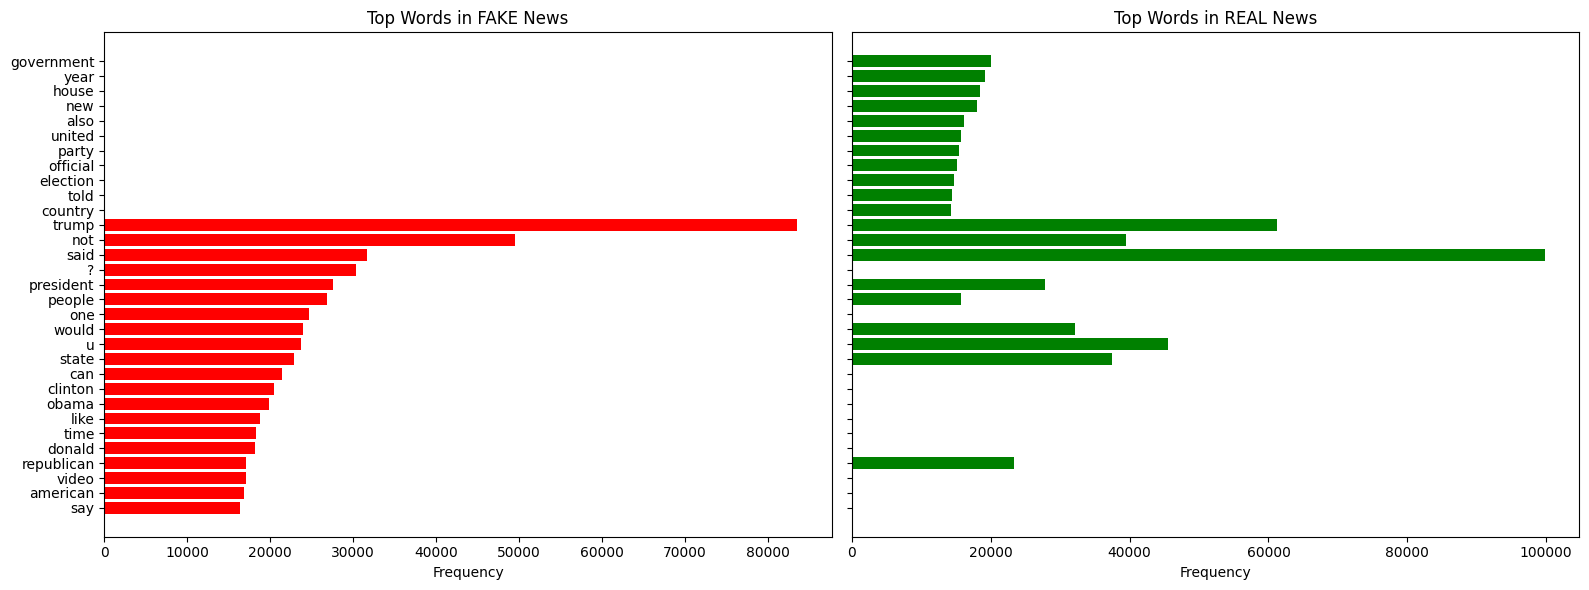

In [5]:
plot_word_frequencies(df_clean_copy.copy(), top_n=20)

# Modelling - Classic Models

In [6]:
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from xgboost import XGBClassifier

MODEL_CONFIG = {
    "nb": {
        "name": "Naive Bayes",
        "model": MultinomialNB(),
    },
    "lr": {
        "name": "Logistic Regression",
        "model": LogisticRegression(max_iter=1000),
    },
    "rf": {
        "name": "Random Forest",
        "model": RandomForestClassifier(n_estimators=500, random_state=42),
    },
    "gb": {
        "name": "Gradient Boosting",
        "model": GradientBoostingClassifier(n_estimators=100, random_state=42),
    },
    "xgb": {
        "name": "XGBoost",
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    },
    "pa": {
        "name": "Passive Aggressive",
        "model": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    },
}

CLASS_NAMES = ["FAKE", "TRUE"]


def encode_labels(y):
    """
    Encode the labels to 0 and 1.
    """
    return np.where(y == "FAKE", 0, 1)



# def show_results(config=MODEL_CONFIG):
#     """
#     Show the results of the models.
#     """
#     for model_key, model_config in config.items():
#         result = model_config["result"]
#         print(f"Model: {model_config['name']}")
#         print(f"Train Accuracy: {result['accuracy_train']:.4f}")
#         print(f"Test Accuracy: {result['accuracy_test']:.4f}")
#         print("Classification Report:")
#         print(result["report"])
#         print("Confusion Matrix:")
#         cm = result["confusion_matrix"]
#         plt.figure(figsize=(5, 4))
#         sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#         plt.xlabel("Predicted")
#         plt.ylabel("Actual")
#         plt.title(f"Confusion Matrix - {model_config['name']}")
#         plt.xticks(ticks=[0.5, 1.5], labels=CLASS_NAMES)
#         plt.show()

def show_results(config=MODEL_CONFIG):
    """
    Show the results of the models with confusion matrix as percentages.
    """
    for model_key, model_config in config.items():
        result = model_config["result"]
        print(f"Model: {model_config['name']}")
        print(f"Train Accuracy: {result['accuracy_train']:.4f}")
        print(f"Test Accuracy: {result['accuracy_test']:.4f}")
        print("Classification Report:")
        print(result["report"])
        print("Confusion Matrix (as percentage):")
        
        cm = result["confusion_matrix"]
        cm_percentage = cm.astype('float') / cm.sum() * 100

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix (%) - {model_config['name']}")
        plt.xticks(ticks=[0.5, 1.5], labels=CLASS_NAMES)
        plt.yticks(ticks=[0.5, 1.5], labels=CLASS_NAMES, rotation=0)
        plt.show()



def vectorize_data(X_train, X_test):
    """
    Vectorize the data using TfidfVectorizer.
    """
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)

    # save the vectorizer for later use
    # with open("vectorizer.pkl", "wb") as f:
    #     pickle.dump(vectorizer, f)

    return X_train_vectorized, X_test_vectorized, vectorizer


def train_test_models(X_train, y_train, X_test, y_test):
    """
    Train the models and evaluate them.
    """
    for model_key, model_config in MODEL_CONFIG.items():
        model = model_config["model"]
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        report = classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)
        cm = confusion_matrix(y_test, y_test_pred)

        result = {
            "name": model_config["name"],
            "accuracy_train": accuracy_train,
            "accuracy_test": accuracy_test,
            "report": report,
            "confusion_matrix": cm,
        }
        MODEL_CONFIG[model_key]["result"] = result
        MODEL_CONFIG[model_key]["model"] = model


def save_models(vectorizer, config=MODEL_CONFIG):
    """
    Save the trained models to disk.
    """
    # save the vectorizer
    with open("./output/vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)

    for model_key, model_config in config.items():
        model = model_config["model"]
        with open(f"./output/{model_key}.pkl", "wb") as f:
            pickle.dump(model, f)


# check if the models already saved
# return true, if they are already saved and load them
# return false, if they are not saved
def load_models():
    try:
        with open("./output/vectorizer.pkl", "rb") as f:
            vectorizer = pickle.load(f)
        for model_key in MODEL_CONFIG.keys():
            with open(f"../output/{model_key}.pkl", "rb") as f:
                model = pickle.load(f)
                MODEL_CONFIG[model_key]["model"] = model
        return True, vectorizer
    except FileNotFoundError:
        return False, None
    except Exception as e:
        print(f"Error loading models: {e}")
        return False, None


# function to test the models
def test_models(X_train, X_test, y_train, y_test):
    """
    Test the models and show the results.
    """
    for model_key, model_config in MODEL_CONFIG.items():
        model = model_config["model"]
        y_train_pred = model.predict(X_train)
        accuracy_train = accuracy_score(y_train, y_train_pred)
        y_test_pred = model.predict(X_test)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        report = classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)
        cm = confusion_matrix(y_test, y_test_pred)

        result = {
            "name": model_config["name"],
            "accuracy_train": accuracy_train,
            "accuracy_test": accuracy_test,
            "report": report,
            "confusion_matrix": cm,
        }
        MODEL_CONFIG[model_key]["result"] = result


def train_classic_models(df):
    X = df["cleaned_news"]
    y = encode_labels(df["label"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_train_vectorized, X_test_vectorized, vectorizer = vectorize_data(X_train, X_test)
    # check if the models are already saved
    models_loaded, vectorizer = load_models()
    if models_loaded:
        print("Models already trained and saved. Loading them...")
        # test the models
        test_models(X_train_vectorized, X_test_vectorized, y_train, y_test)
    else:
        print("Training models...")
        # train and test the models
        train_test_models(X_train_vectorized, y_train, X_test_vectorized, y_test)
        # save the models
        print("Saving models...")
        save_models(vectorizer)

    show_results()
    return MODEL_CONFIG, vectorizer


Training models...


c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:12:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saving models...
Model: Naive Bayes
Train Accuracy: 0.9275
Test Accuracy: 0.9273
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.93      7108
        TRUE       0.93      0.92      0.92      6488

    accuracy                           0.93     13596
   macro avg       0.93      0.93      0.93     13596
weighted avg       0.93      0.93      0.93     13596

Confusion Matrix (as percentage):


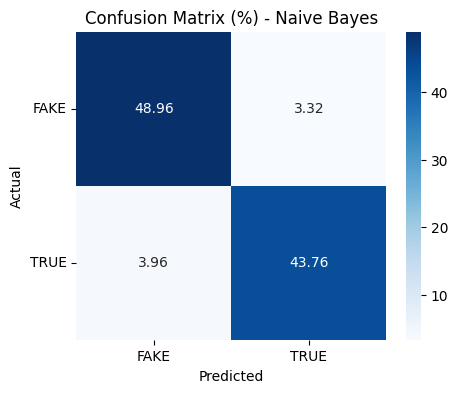

Model: Logistic Regression
Train Accuracy: 0.9825
Test Accuracy: 0.9765
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.98      7108
        TRUE       0.97      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


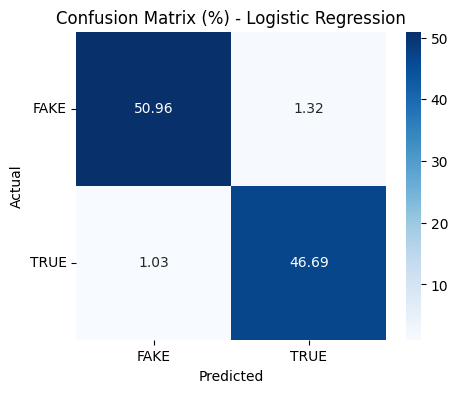

Model: Random Forest
Train Accuracy: 0.9981
Test Accuracy: 0.9798
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


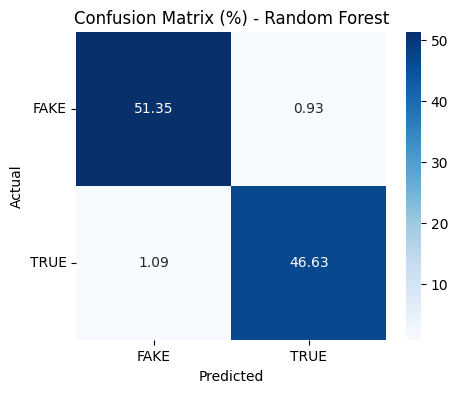

Model: Gradient Boosting
Train Accuracy: 0.9627
Test Accuracy: 0.9554
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.96      0.95      0.96      7108
        TRUE       0.95      0.96      0.95      6488

    accuracy                           0.96     13596
   macro avg       0.96      0.96      0.96     13596
weighted avg       0.96      0.96      0.96     13596

Confusion Matrix (as percentage):


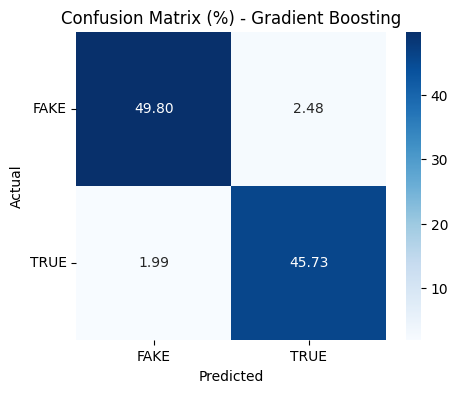

Model: XGBoost
Train Accuracy: 0.9969
Test Accuracy: 0.9840
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


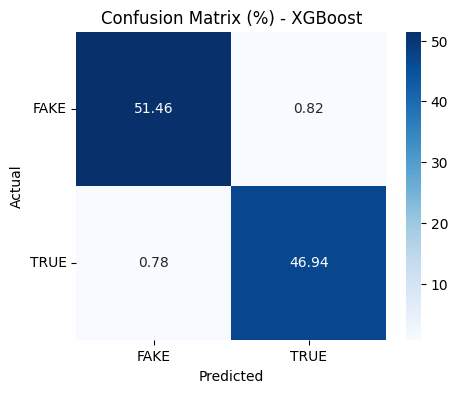

Model: Passive Aggressive
Train Accuracy: 0.9980
Test Accuracy: 0.9812
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


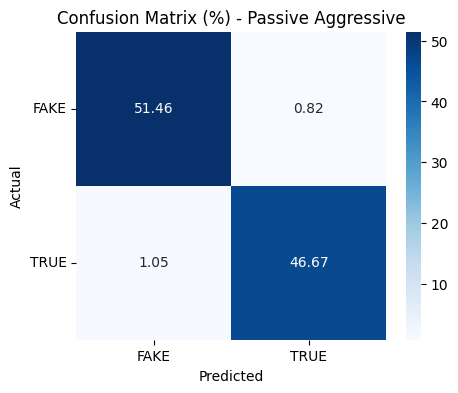

In [7]:
model_config, vectorizer = train_classic_models(df_clean_copy.copy())

In [8]:
# https://www.kaggle.com/code/jaskaransingh/fake-news-classification-bert-roberta

## Hyperparameter Tuning



In [11]:
from sklearn.model_selection import GridSearchCV

TUNING_CONFIG = {
    "lr": {
        "param_grid": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["liblinear", "saga"]
        }
    },
    "nb": {
        "param_grid": {
            "alpha": [0.1, 0.5, 1.0]
        }
    },
    "rf": {
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "gb": {
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "xgb": {
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.01, 0.1],
            "tree_method": ["gpu_hist"],
            "predictor": ["gpu_predictor"]
        }
    },
    "pa": {
        "param_grid": {
            "C": [0.01, 0.1, 1.0],
            "loss": ["hinge", "squared_hinge"]
        }
    }
}

def tune_model(model_key, model, X_train, y_train):
    if model_key not in TUNING_CONFIG:
        print(f"No tuning config for {model_key}")
        return model
    
    print(f"Tuning {MODEL_CONFIG[model_key]['name']}...")
    param_grid = TUNING_CONFIG[model_key]["param_grid"]
    
    grid = GridSearchCV(model, param_grid, cv=5, scoring="f1", verbose=1, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"Best Params for {MODEL_CONFIG[model_key]['name']}: {grid.best_params_}")
    print(f"Best Score for {MODEL_CONFIG[model_key]['name']}: {grid.best_score_:.4f}")
    return grid.best_estimator_

def train_test_tune_models(X_train, y_train, X_test, y_test):
    for model_key, model_config in MODEL_CONFIG.items():
        model = model_config["model"]
        
        # Try tuning the model
        model = tune_model(model_key, model, X_train, y_train)

        # Train and evaluate
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        report = classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)
        cm = confusion_matrix(y_test, y_test_pred)

        result = {
            "name": model_config["name"],
            "accuracy_train": accuracy_train,
            "accuracy_test": accuracy_test,
            "report": report,
            "confusion_matrix": cm,
        }

        MODEL_CONFIG[model_key]["result"] = result
        MODEL_CONFIG[model_key]["model"] = model

def tune_test_classic_models(df):
    X = df["cleaned_news"]
    y = encode_labels(df["label"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print("Training models...")
    # vectorize the data
    X_train_vectorized, X_test_vectorized, vectorizer = vectorize_data(X_train, X_test)
    # train and test the models
    train_test_tune_models(X_train_vectorized, y_train, X_test_vectorized, y_test)
    # save the best models
    print("Saving best models...")
    save_models(vectorizer)

    show_results()
    return MODEL_CONFIG, vectorizer

Training models...
Tuning Naive Bayes...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params for Naive Bayes: {'alpha': 0.1}
Best Score for Naive Bayes: 0.9210
Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.9813
Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score for Random Forest: 0.9752
Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Score for Gradient Boosting: 0.9762
Tuning XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'predictor': 'gpu_predictor', 'tree_method': 'gpu_hist'}
Best Score for XGBoost: 0.7455


c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\xgboost\core.py:2676: UserWarning: [19:30:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", de

Tuning Passive Aggressive...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params for Passive Aggressive: {'C': 0.01, 'loss': 'squared_hinge'}
Best Score for Passive Aggressive: 0.9815
Saving best models...
Model: Naive Bayes
Train Accuracy: 0.9281
Test Accuracy: 0.9282
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.93      7108
        TRUE       0.93      0.92      0.92      6488

    accuracy                           0.93     13596
   macro avg       0.93      0.93      0.93     13596
weighted avg       0.93      0.93      0.93     13596

Confusion Matrix (as percentage):


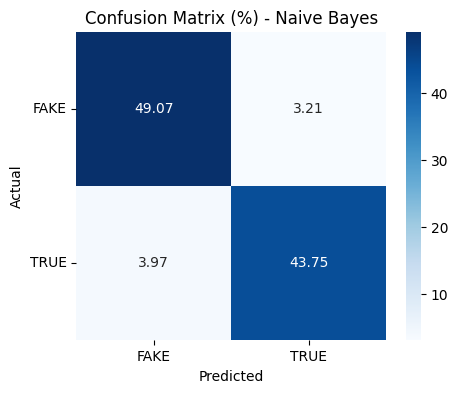

Model: Logistic Regression
Train Accuracy: 0.9939
Test Accuracy: 0.9835
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


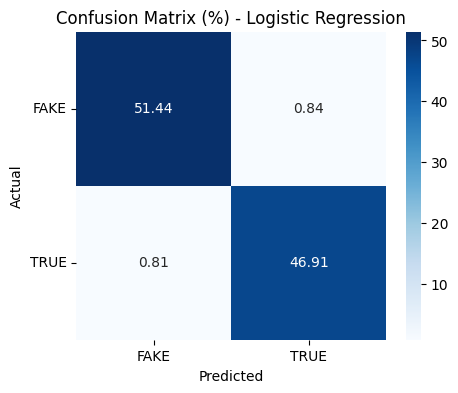

Model: Random Forest
Train Accuracy: 0.9981
Test Accuracy: 0.9800
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


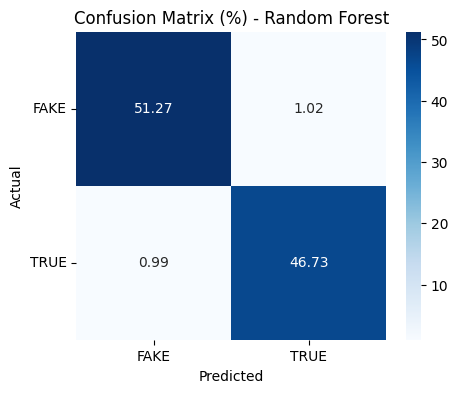

Model: Gradient Boosting
Train Accuracy: 0.9949
Test Accuracy: 0.9774
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


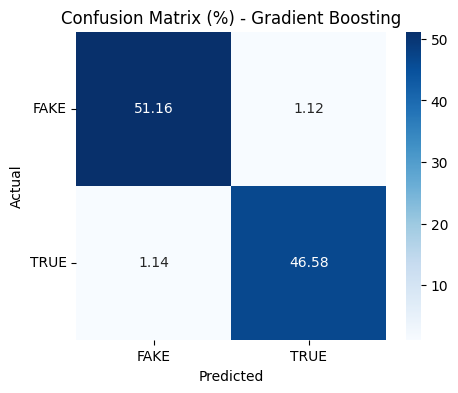

Model: XGBoost
Train Accuracy: 0.7497
Test Accuracy: 0.7479
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.76      0.76      0.76      7108
        TRUE       0.74      0.73      0.73      6488

    accuracy                           0.75     13596
   macro avg       0.75      0.75      0.75     13596
weighted avg       0.75      0.75      0.75     13596

Confusion Matrix (as percentage):


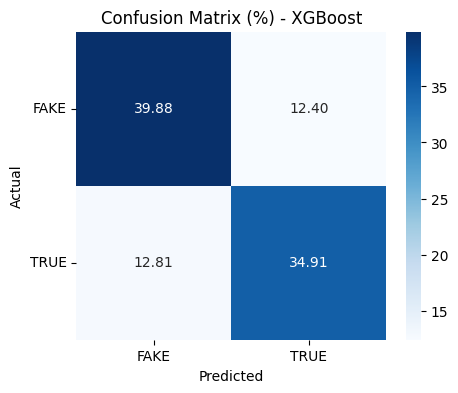

Model: Passive Aggressive
Train Accuracy: 0.9923
Test Accuracy: 0.9837
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix (as percentage):


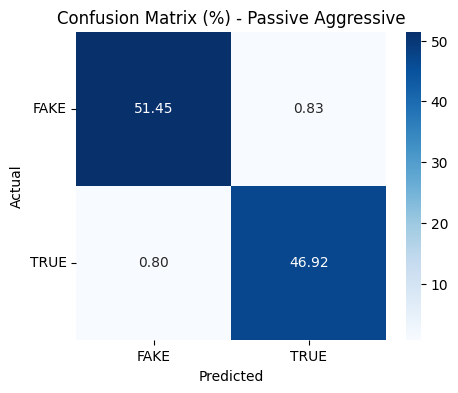

({'nb': {'name': 'Naive Bayes',
   'model': MultinomialNB(alpha=0.1),
   'result': {'name': 'Naive Bayes',
    'accuracy_train': 0.9280670785525155,
    'accuracy_test': 0.9282141806413651,
    'report': '              precision    recall  f1-score   support\n\n        FAKE       0.93      0.94      0.93      7108\n        TRUE       0.93      0.92      0.92      6488\n\n    accuracy                           0.93     13596\n   macro avg       0.93      0.93      0.93     13596\nweighted avg       0.93      0.93      0.93     13596\n',
    'confusion_matrix': array([[6672,  436],
           [ 540, 5948]])}},
  'lr': {'name': 'Logistic Regression',
   'model': LogisticRegression(C=10, max_iter=1000, solver='liblinear'),
   'result': {'name': 'Logistic Regression',
    'accuracy_train': 0.9938847560206784,
    'accuracy_test': 0.9835245660488379,
    'report': '              precision    recall  f1-score   support\n\n        FAKE       0.98      0.98      0.98      7108\n        TRUE    

In [12]:
tune_test_classic_models(df_clean_copy.copy())